In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import plot_frequency_recency_matrix

data = pd.read_csv('../data/flo_final.csv')
df   = pd.read_csv('../data/flo_processed.csv', parse_dates=[
    'first_order_date', 'last_order_date',
    'last_order_date_online', 'last_order_date_offline'
])

ANALYSIS_DATE = pd.Timestamp('2021-06-01')

print(f"Data shape: {data.shape}")
data.head(3)

Data shape: (19945, 16)


,customer_id,recency,frequency,monetary,churn,online_ratio,avg_order_value,customer_lifetime_days,num_categories,cat_kadin,cat_erkek,cat_cocuk,cat_aktifspor,cat_aktifcocuk,churn_probability,churn_risk
0,cc294636-19f0-11eb-8d74-000d3a38a36f,95,5.0,939.37,0,0.800000,187.874000,214,1,1,0,0,0,0,0.145693,Low Risk
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,105,21.0,2013.55,0,0.904762,95.883333,1574,4,1,1,1,1,0,0.202545,Low Risk
2,69b69676-1a40-11ea-941b-000d3a38a36f,186,5.0,585.32,1,0.600000,117.064000,552,2,1,1,0,0,0,0.297405,Low Risk


In [2]:
# ── Prepare CLTV dataframe ────────────────────────────────
# BG-NBD needs: frequency, recency, T (age)
# frequency = number of repeat purchases (total - 1)
# recency   = weeks between first and last purchase
# T         = weeks between first purchase and analysis date

cltv_df = pd.DataFrame()
cltv_df['customer_id']  = df['master_id']

# Convert to weekly units (BG-NBD works better with weeks)
cltv_df['frequency'] = df['total_order'] - 1
cltv_df['recency']   = ((df['last_order_date'] - 
                          df['first_order_date']).dt.days) / 7
cltv_df['T']         = ((ANALYSIS_DATE - 
                          df['first_order_date']).dt.days) / 7
cltv_df['monetary']  = df['total_price'] / df['total_order']

# BG-NBD requires frequency > 0
cltv_df = cltv_df[cltv_df['frequency'] > 0]

print(f"Shape after filter: {cltv_df.shape}")
print()
print(cltv_df[['frequency','recency','T','monetary']].describe().T)

Shape after filter: (19945, 5)

             count        mean        std        min         25%         50%  \
frequency  19945.0    3.874605   3.563218   1.000000    2.000000    3.000000   
recency    19945.0   95.263496  74.589446   0.000000   50.428571   76.571429   
T          19945.0  114.471833  74.770983   0.714286   73.857143   93.000000   
monetary   19945.0  151.647456  71.000423  26.826667  104.127917  137.500769   

                  75%         max  
frequency    5.000000   26.000000  
recency    109.428571  433.428571  
T          119.428571  437.142857  
monetary   181.632000  951.786700  


In [5]:
# ── BG-NBD Model ─────────────────────────────────────────
# Predicts: how many purchases will a customer make?

bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(cltv_df['frequency'],
        cltv_df['recency'],
        cltv_df['T'])

# Predict expected purchases in next 6 months (26 weeks)
cltv_df['expected_purchases_6m'] = bgf.predict(
    26,
    cltv_df['frequency'],
    cltv_df['recency'],
    cltv_df['T']
)

# Check for inf or nan
print(f"Inf values: {np.isinf(cltv_df['expected_purchases_6m']).sum()}")
print(f"NaN values: {cltv_df['expected_purchases_6m'].isna().sum()}")
print(f"\nAvg expected purchases (6 months): "
      f"{cltv_df['expected_purchases_6m'].mean():.2f}")
print(f"Min: {cltv_df['expected_purchases_6m'].min():.2f}")
print(f"Max: {cltv_df['expected_purchases_6m'].max():.2f}")

Inf values: 0
NaN values: 0

Avg expected purchases (6 months): 0.97
Min: 0.18
Max: 6.83


/Users/nehir/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
# ── Gamma-Gamma Model ─────────────────────────────────────
# Predicts: how much will a customer spend per purchase?

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(cltv_df['frequency'],
        cltv_df['monetary'])

print("Gamma-Gamma model fitted successfully!")

# Expected average profit per transaction
cltv_df['expected_avg_value'] = ggf.conditional_expected_average_profit(
    cltv_df['frequency'],
    cltv_df['monetary']
)

# ── Final CLTV ────────────────────────────────────────────
cltv_df['cltv_6m'] = (cltv_df['expected_purchases_6m'] * 
                       cltv_df['expected_avg_value'])

print(f"\nAvg CLTV (6 months) : {cltv_df['cltv_6m'].mean():.2f} TL")
print(f"Max CLTV (6 months) : {cltv_df['cltv_6m'].max():.2f} TL")
print(f"Min CLTV (6 months) : {cltv_df['cltv_6m'].min():.2f} TL")

Gamma-Gamma model fitted successfully!

Avg CLTV (6 months) : 157.77 TL
Max CLTV (6 months) : 2061.94 TL
Min CLTV (6 months) : 9.92 TL


In [7]:
# ── CLTV Segments ─────────────────────────────────────────

cltv_df['cltv_segment'] = pd.qcut(cltv_df['cltv_6m'], q=4,
                                   labels=['Bronze', 'Silver', 
                                           'Gold', 'Platinum'])

print("CLTV Segment distribution:")
print(cltv_df.groupby('cltv_segment').agg(
    num_customers=('customer_id', 'count'),
    avg_cltv=('cltv_6m', 'mean'),
    avg_purchases=('expected_purchases_6m', 'mean'),
    avg_order_value=('expected_avg_value', 'mean')
).round(2))

# Save
cltv_df.to_csv('../data/flo_cltv.csv', index=False)
print("\nSaved → flo_cltv.csv")

CLTV Segment distribution:
              num_customers  avg_cltv  avg_purchases  avg_order_value
cltv_segment                                                         
Bronze                 4987     60.05           0.60           107.05
Silver                 4986    107.23           0.81           142.26
Gold                   4986    160.39           1.01           174.55
Platinum               4986    303.43           1.44           231.31

Saved → flo_cltv.csv


In [8]:
# ── Merge everything: RFM + Churn + CLTV ─────────────────

final = pd.read_csv('../data/flo_final.csv')

final = final.merge(
    cltv_df[['customer_id', 'cltv_6m', 'cltv_segment', 
              'expected_purchases_6m', 'expected_avg_value']],
    on='customer_id',
    how='left'
)

# Add RFM segment
rfm = pd.read_csv('../data/flo_rfm.csv')
final = final.merge(
    rfm[['customer_id', 'segment', 'kmeans_segment', 'RF_score']],
    on='customer_id',
    how='left'
)

print(f"Final dataset shape: {final.shape}")
print(f"Columns: {list(final.columns)}")

final.to_csv('../data/flo_master.csv', index=False)
print("\nSaved → flo_master.csv")

Final dataset shape: (19945, 23)
Columns: ['customer_id', 'recency', 'frequency', 'monetary', 'churn', 'online_ratio', 'avg_order_value', 'customer_lifetime_days', 'num_categories', 'cat_kadin', 'cat_erkek', 'cat_cocuk', 'cat_aktifspor', 'cat_aktifcocuk', 'churn_probability', 'churn_risk', 'cltv_6m', 'cltv_segment', 'expected_purchases_6m', 'expected_avg_value', 'segment', 'kmeans_segment', 'RF_score']

Saved → flo_master.csv


In [10]:
# ── Priority Matrix: CLTV × Churn Risk ───────────────────

matrix = final.groupby(['cltv_segment', 'churn_risk']).agg(
    num_customers=('customer_id', 'count'),
    avg_cltv=('cltv_6m', 'mean'),
    avg_churn_prob=('churn_probability', 'mean')
).round(2)

print(matrix)
print()

# Most critical group: High CLTV + High Churn Risk
critical = final[(final['cltv_segment'] == 'Platinum') & 
                 (final['churn_risk'] == 'High Risk')]

print(f"  Critical customers (Platinum + High Risk): {len(critical)}")
print(f"   Avg CLTV  : {critical['cltv_6m'].mean():.2f} TL")
print(f"   Avg Churn : {critical['churn_probability'].mean()*100:.1f}%")

                          num_customers  avg_cltv  avg_churn_prob
cltv_segment churn_risk                                          
Bronze       High Risk              396     41.18            0.65
             Low Risk               852     63.55            0.11
             Medium Risk           3739     61.25            0.47
Silver       High Risk               29    103.76            0.62
             Low Risk              1319    109.17            0.16
             Medium Risk           3638    106.56            0.42
Gold         High Risk               23    157.71            0.62
             Low Risk              2308    162.99            0.19
             Medium Risk           2655    158.14            0.39
Platinum     High Risk               24    305.76            0.65
             Low Risk              3697    316.21            0.17
             Medium Risk           1265    266.06            0.38

  Critical customers (Platinum + High Risk): 24
   Avg CLTV  : 305.76 TL
  

In [13]:
# ── Key Overlap Findings ──────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

master = pd.read_csv('../data/flo_master.csv')

print("=" * 55)
print("SEGMENT COMPARISON — KEY FINDINGS")
print("=" * 55)

segments = master['segment'].unique()

for seg in sorted(segments):
    subset = master[master['segment'] == seg]
    top_kmeans = subset['kmeans_segment'].value_counts().index[0]
    top_pct = subset['kmeans_segment'].value_counts(normalize=True).iloc[0] * 100
    print(f"{seg:22s} → K-Means: {top_kmeans:20s} ({top_pct:.1f}%)")

print()
print("Champions overlap (both methods):")
both = master[(master['segment']=='Champions') & 
              (master['kmeans_segment']=='Champions')]
print(f"  {len(both)} customers ({len(both)/len(master[master['segment']=='Champions'])*100:.1f}% of RFM Champions)")
print(f"  Avg monetary: {both['monetary'].mean():.0f} TL")
print(f"  Avg frequency: {both['frequency'].mean():.1f} orders")

SEGMENT COMPARISON — KEY FINDINGS
About to Sleep         → K-Means: Potential Loyalists  (99.8%)
At Risk                → K-Means: At Risk              (83.5%)
Cannot Lose Them       → K-Means: Loyal Customers      (52.2%)
Champions              → K-Means: Loyal Customers      (52.0%)
Hibernating            → K-Means: At Risk              (88.2%)
Loyal Customers        → K-Means: Loyal Customers      (55.3%)
Need Attention         → K-Means: Potential Loyalists  (95.7%)
New Customers          → K-Means: Potential Loyalists  (99.9%)
Potential Loyalists    → K-Means: Potential Loyalists  (97.3%)
Promising              → K-Means: Potential Loyalists  (99.8%)

Champions overlap (both methods):
  299 customers (15.5% of RFM Champions)
  Avg monetary: 2732 TL
  Avg frequency: 16.5 orders


In [14]:
# ── Priority Score: CLTV × Churn Risk ────────────────────
# Logic: high CLTV + high churn probability = most urgent to save

final = pd.read_csv('../data/flo_master.csv')

# Normalize CLTV and churn probability to 0-1 scale
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
final['cltv_norm']  = scaler.fit_transform(final[['cltv_6m']])
final['churn_norm'] = final['churn_probability']

# Priority score: weighted combination
# 60% CLTV importance, 40% churn risk
final['priority_score'] = (0.6 * final['cltv_norm'] + 
                            0.4 * final['churn_norm'])

# Rank customers
final['priority_rank'] = final['priority_score'].rank(
    ascending=False).astype(int)

print("Top 10 Priority Customers:")
print(final.nlargest(10, 'priority_score')[
    ['customer_id', 'cltv_6m', 'churn_probability', 
     'priority_score', 'priority_rank', 'segment']
].to_string())

Top 10 Priority Customers:
                                customer_id      cltv_6m  churn_probability  priority_score  priority_rank              segment
8868   9ce6e520-89b0-11ea-a6e7-000d3a38a36f  1453.919151           0.627241        0.673114              1     Cannot Lose Them
9055   47a642fe-975b-11eb-8c2a-000d3a38a36f  2061.941134           0.026072        0.610429              2  Potential Loyalists
7936   ae4ce104-dbd4-11ea-8757-000d3a38a36f   978.379263           0.516508        0.489775              3          Hibernating
13880  7137a5c0-7aad-11ea-8f20-000d3a38a36f  1545.795942           0.019960        0.457066              4      Loyal Customers
6717   40b4f318-9dfb-11eb-9c47-000d3a38a36f  1157.878705           0.269289        0.443373              5      Loyal Customers
11694  90f1b7f2-bbad-11ea-a0c9-000d3a38a36f  1087.162046           0.234412        0.408745              6            Champions
16410  6fecd6c8-261a-11ea-8e1c-000d3a38a36f   524.436237           0.645262  

In [17]:
# ── Priority Tiers via Percentile ─────────────────────────

final['priority_tier'] = pd.qcut(
    final['priority_score'],
    q=[0, 0.70, 0.90, 0.97, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)

print("Priority Tier Distribution:")
print(final['priority_tier'].value_counts().sort_index())
print()

critical = final[final['priority_tier'] == 'Critical']
print(f"Critical customers : {len(critical)}")
print(f"Avg CLTV           : {critical['cltv_6m'].mean():.2f} TL")
print(f"Avg Churn Prob     : {critical['churn_probability'].mean()*100:.1f}%")
print()
print("Critical by RFM segment:")
print(critical['segment'].value_counts())

final.to_csv('../data/flo_master.csv', index=False)
print("\nSaved!")

Priority Tier Distribution:
priority_tier
Low         13961
Medium       3989
High         1396
Critical      599
Name: count, dtype: int64

Critical customers : 599
Avg CLTV           : 264.28 TL
Avg Churn Prob     : 53.4%

Critical by RFM segment:
segment
Hibernating            357
About to Sleep          54
At Risk                 36
Champions               33
Loyal Customers         27
Promising               24
Cannot Lose Them        23
Potential Loyalists     21
New Customers           19
Need Attention           5
Name: count, dtype: int64

Saved!


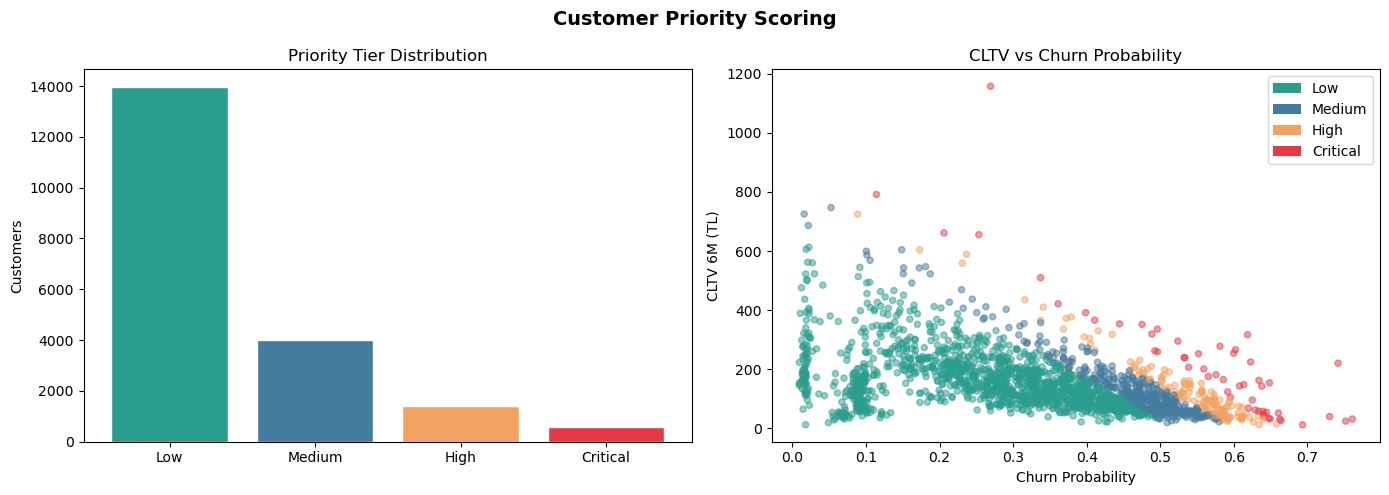

Saved!


In [18]:
# ── Priority Score Visualization ─────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Priority Scoring', fontsize=14, fontweight='bold')

# Plot 1: Tier distribution
tier_counts = final['priority_tier'].value_counts().sort_index()
colors = ['#2A9D8F', '#457B9D', '#F4A261', '#E63946']
axes[0].bar(tier_counts.index, tier_counts.values, 
            color=colors, edgecolor='white')
axes[0].set_title('Priority Tier Distribution')
axes[0].set_ylabel('Customers')

# Plot 2: CLTV vs Churn colored by priority
sample = final.sample(2000, random_state=42)
color_map = {'Low': '#2A9D8F', 'Medium': '#457B9D',
             'High': '#F4A261', 'Critical': '#E63946'}
scatter_colors = sample['priority_tier'].map(color_map)

axes[1].scatter(sample['churn_probability'], sample['cltv_6m'],
                c=scatter_colors, alpha=0.5, s=20)
axes[1].set_title('CLTV vs Churn Probability')
axes[1].set_xlabel('Churn Probability')
axes[1].set_ylabel('CLTV 6M (TL)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
axes[1].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/week4_priority_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")